In [2]:
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score, auc, roc_curve

In [3]:
DATA_PATH = Path.cwd().parent / "data" / "interim"

X_train = joblib.load(DATA_PATH / "X_train.pkl")
y_train = joblib.load(DATA_PATH / "y_train.pkl")
X_test = joblib.load(DATA_PATH / "X_test.pkl")
y_test = joblib.load(DATA_PATH / "y_test.pkl")
preprocessor = joblib.load(DATA_PATH / "preprocessor.pkl")


In [4]:
# Ajustar el preprocesador y transformar los datos de entrenamiento
X_train_processed = preprocessor.fit_transform(X_train)

# Transformar los datos de prueba usando los parámetros aprendidos
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape, X_test_processed.shape)

(36168, 45) (9043, 45)


# Métricas

In [7]:
def calculate_classification_metrics(y_real, predictions, probabilities ) -> dict:
    """
    Calcula métricas de clasificacion
    """
    
    return {
        "accuracy": accuracy_score(y_real, predictions),
        "precision": precision_score(y_real, predictions),
        "recall": recall_score(y_real, predictions),
        "f1_score": f1_score(y_real, predictions),
        "auc_score": roc_auc_score(y_real, probabilities)   # El cálculo de ROC AUC necesita las probabilidades de la clase positiva, porque así puede construir la curva ROC variando el umbral de decisión.
    }

In [8]:
def confusion_matrix_bank_mark(y_real, predictions):
    cm = confusion_matrix(y_real, predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
    disp.plot(cmap="Blues")
    plt.title('Confusion Matrix - Bank Marketing Model')
    plt.show()

In [9]:
def roc_curve_graph(y_real, probabilities):
    # verdaderos positivos, falsos positivos, umbral de probabilidad 
    tpr, fpr, _ = roc_curve(y_real, probabilities, pos_label=1 )

    # tasa de falsos positivos vs tasa de verdaderos positivos
    sns.lineplot(x=fpr, y=tpr)

# Entrenamiento

## Modelo lineal simple

In [8]:
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_processed, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [9]:
y_pred_lr = model_lr.predict(X_test_processed)

In [10]:
y_prob_lr = model_lr.predict_proba(X_test_processed)

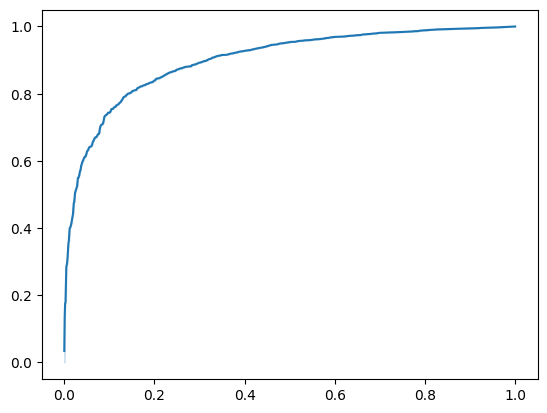

In [11]:
roc_curve_graph(y_real=y_test, probabilities=y_prob_lr[:,0])

In [12]:
calculate_classification_metrics(y_real=y_test, predictions=y_pred_lr, probabilities=y_prob_lr[:,1])

{'accuracy': 0.8991485126617274,
 'precision': 0.6595365418894831,
 'recall': 0.3391384051329056,
 'f1_score': 0.44794188861985473,
 'auc_score': 0.9009379374321087}

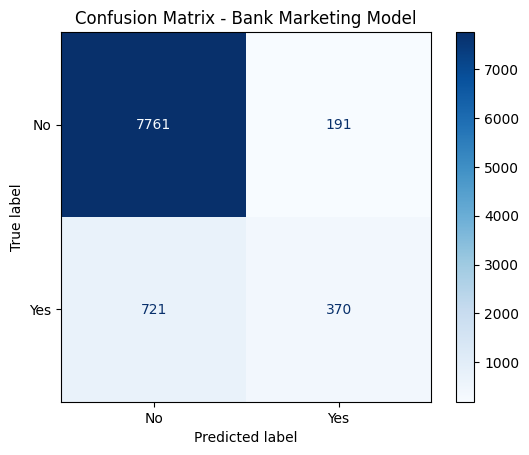

In [13]:
confusion_matrix_bank_mark(y_real=y_test, predictions=y_pred_lr)

## Modelo no lineal para capturar relaciones más complejas entre las features

In [14]:
model_rfc = RandomForestClassifier(class_weight='balanced', random_state=42)
model_rfc.fit(X_train_processed, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
y_pred_rfc = model_rfc.predict(X_test_processed)

In [16]:
y_prob_rfc = model_lr.predict_proba(X_test_processed)

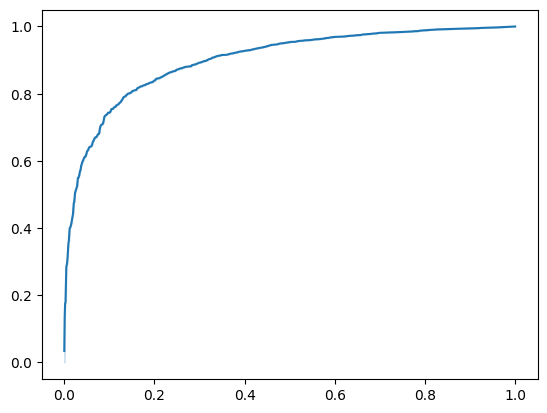

In [17]:
roc_curve_graph(y_real=y_test, probabilities=y_prob_rfc[:,0])

In [18]:
calculate_classification_metrics(y_real=y_test, predictions=y_pred_rfc, probabilities=y_prob_rfc[:,1])

{'accuracy': 0.8987061815769103,
 'precision': 0.6593806921675774,
 'recall': 0.3318056828597617,
 'f1_score': 0.44146341463414634,
 'auc_score': 0.9009379374321087}

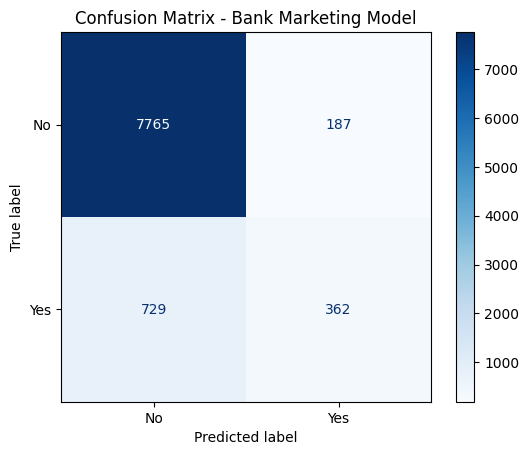

In [19]:
confusion_matrix_bank_mark(y_real=y_test, predictions=y_pred_rfc)

## Ensamble con Boosting

In [20]:
!uv add xgboost

Resolved 81 packages in 0.48ms
Audited 80 packages in 0.16ms


In [4]:
import xgboost as xgb
from sklearn.pipeline import Pipeline

In [5]:
model_xgb = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

pipeline_xgb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model_xgb)
])

# Entrenar el modelo
pipeline_xgb.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [6]:
y_pred_xgb = pipeline_xgb.predict(X_test)
y_prob_xgb = pipeline_xgb.predict_proba(X_test)

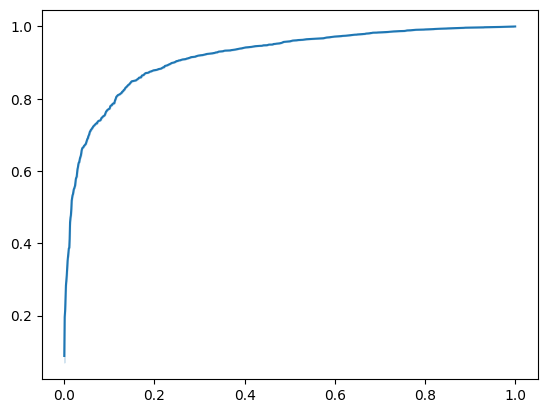

In [10]:
roc_curve_graph(y_real=y_test, probabilities=y_prob_xgb[:,0])

In [11]:
calculate_classification_metrics(y_real=y_test, predictions=y_pred_xgb, probabilities=y_prob_xgb[:,1])

{'accuracy': 0.9036824062811014,
 'precision': 0.6432291666666666,
 'recall': 0.45279560036663613,
 'f1_score': 0.5314685314685315,
 'auc_score': 0.9177911188487478}

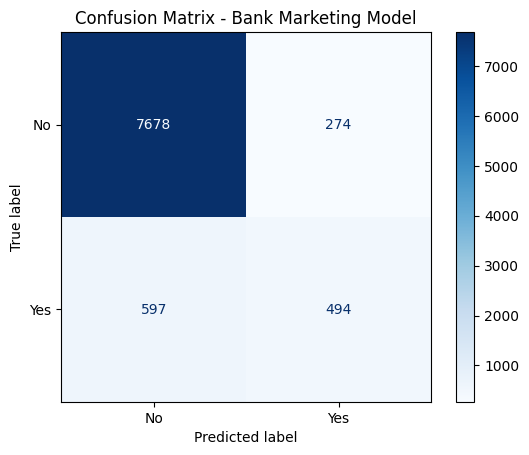

In [12]:
confusion_matrix_bank_mark(y_real=y_test, predictions=y_pred_xgb)

# Evaluar modelos

In [27]:
from sklearn.metrics import classification_report

print("\n📊 MÉTRICAS DEL RANDOM FOREST")
print(classification_report(y_test, y_pred_rfc))


📊 MÉTRICAS DEL RANDOM FOREST
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7952
           1       0.66      0.33      0.44      1091

    accuracy                           0.90      9043
   macro avg       0.79      0.65      0.69      9043
weighted avg       0.88      0.90      0.88      9043



In [28]:
print("\n📊 MÉTRICAS DE LOGISTIC REGRESSION ")
print(classification_report(y_test, y_pred_lr))


📊 MÉTRICAS DE LOGISTIC REGRESSION 
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7952
           1       0.66      0.34      0.45      1091

    accuracy                           0.90      9043
   macro avg       0.79      0.66      0.70      9043
weighted avg       0.88      0.90      0.88      9043



In [37]:
print("\n📊 MÉTRICAS DE XGBOOST ")
print(classification_report(y_test, y_pred_xgb))


📊 MÉTRICAS DE XGBOOST 
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7952
           1       0.64      0.45      0.53      1091

    accuracy                           0.90      9043
   macro avg       0.79      0.71      0.74      9043
weighted avg       0.89      0.90      0.90      9043



# Guardar modelo entrenado con mejor rendimiento para etapa de Interpretabilidad

In [22]:
MODELS_DIR = Path.cwd().parent / "models"
MODELS_DIR.mkdir(exist_ok=True)

In [23]:
# pipeline_xgb.named_steps["model"].save_model(MODELS_DIR / "xgb_classifier_model.pkl")
joblib.dump(pipeline_xgb, MODELS_DIR / "pipeline_xgb.pkl")

['/home/edyn/Escritorio/project_edyN/MLEngineer/mle-III/models/pipeline_xgb.pkl']